In this document, we test the final two models and evaluate on their metrics

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import os

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

from sklearn.linear_model import LinearRegression


from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [3]:
def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,    
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path, 
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [4]:
train_test_split_data_loc = '../../data/schedule_data/train_test_split_data/by_day_short_and_long/'
train_daily_df = read_csv(os.path.join(train_test_split_data_loc, 'schedule_data_by_day_short_long_train.csv'))
test_daily_df = read_csv(os.path.join(train_test_split_data_loc, 'schedule_data_by_day_short_long_test.csv'))

In [5]:
# I want to add daily weather data
weather_loc = '../../raw_data/Weatherstats_data'
## Since we have already decided on the features we want to use, we will only read those columns in
weather=pd.read_csv(os.path.join(weather_loc, 'weatherstats_toronto_daily.csv')
                    , usecols=['date','avg_temperature', 'avg_wind_speed',
                               'avg_visibility', 'avg_health_index', 'rain',
                               'snow_on_ground', 'daylight'])
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)


In [6]:
# Now I will merge the weather data into the training and testing dataframes

for name, df in [("train df", train_daily_df),( "test df", test_daily_df)]:
    
    df = df.copy()
    df.date = df.date.apply(pd.Timestamp)
    df = df.rename(columns={
    'delay time (5,19]':'dt_short', 
    'delay time (19,120]':'dt_long', 
    'EB/WB':'dir'
    })

    # We will also add a column for the transformed bunching 
    df['log_bunch'] = np.log1p(df['bunch'])



    first_date = df['date'].min()
    last_date = df['date'].max()
    temp_weather = weather[weather['date'].between(first_date,last_date)]
    

    df = pd.merge(df, temp_weather, on='date')

    # Fill any n/a values with zeros
    
    df.fillna(0, inplace=True)

    ## Turn stop information and direction into categorical features.
    df['stop']=df['stop'].astype('category')
    df['dir']=df['dir'].astype('category')
   
    if name == "train df":
        train_daily_df = df
    else:
        test_daily_df = df

In [7]:
train_daily_df.tail()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,RT dist (km),Interruption,log_bunch,avg_temperature,avg_wind_speed,avg_visibility,avg_health_index,rain,snow_on_ground,daylight
58103,2025-08-31,W,Coxwell Ave at Lower Gerrard St East,0,0,0.000000,0.000000,14.8,135.6,13.2,...,30.13,0,0.000000,16.39,8.5,24100,2.0,0.0,0.0,13.25
58104,2025-08-31,W,Coxwell Ave at Gerrard St East,3,10,151.816667,48.600000,14.8,135.6,13.2,...,30.13,0,1.386294,16.39,8.5,24100,2.0,0.0,0.0,13.25
58105,2025-08-31,W,Main St at Gerrard St East,0,0,0.000000,0.000000,14.8,135.6,13.2,...,30.13,0,0.000000,16.39,8.5,24100,2.0,0.0,0.0,13.25
58106,2025-08-31,W,Queens Park (Queen's Park Station),0,0,0.000000,0.000000,14.8,135.6,13.2,...,30.13,0,0.000000,16.39,8.5,24100,2.0,0.0,0.0,13.25
58107,2025-08-31,E,Leslie St,10,13,331.216667,99.083333,14.8,135.6,13.2,...,30.13,0,2.397895,16.39,8.5,24100,2.0,0.0,0.0,13.25


In [8]:
features = ['dir', 'log_bunch', 'bunch', 'gap', 'stop', 'dir']+weather.columns.to_list()
targets = [x for x in train_daily_df.columns if 'dt_' in x]

In [9]:
corr_matrix = train_daily_df[features+targets].select_dtypes(np.number).corr()

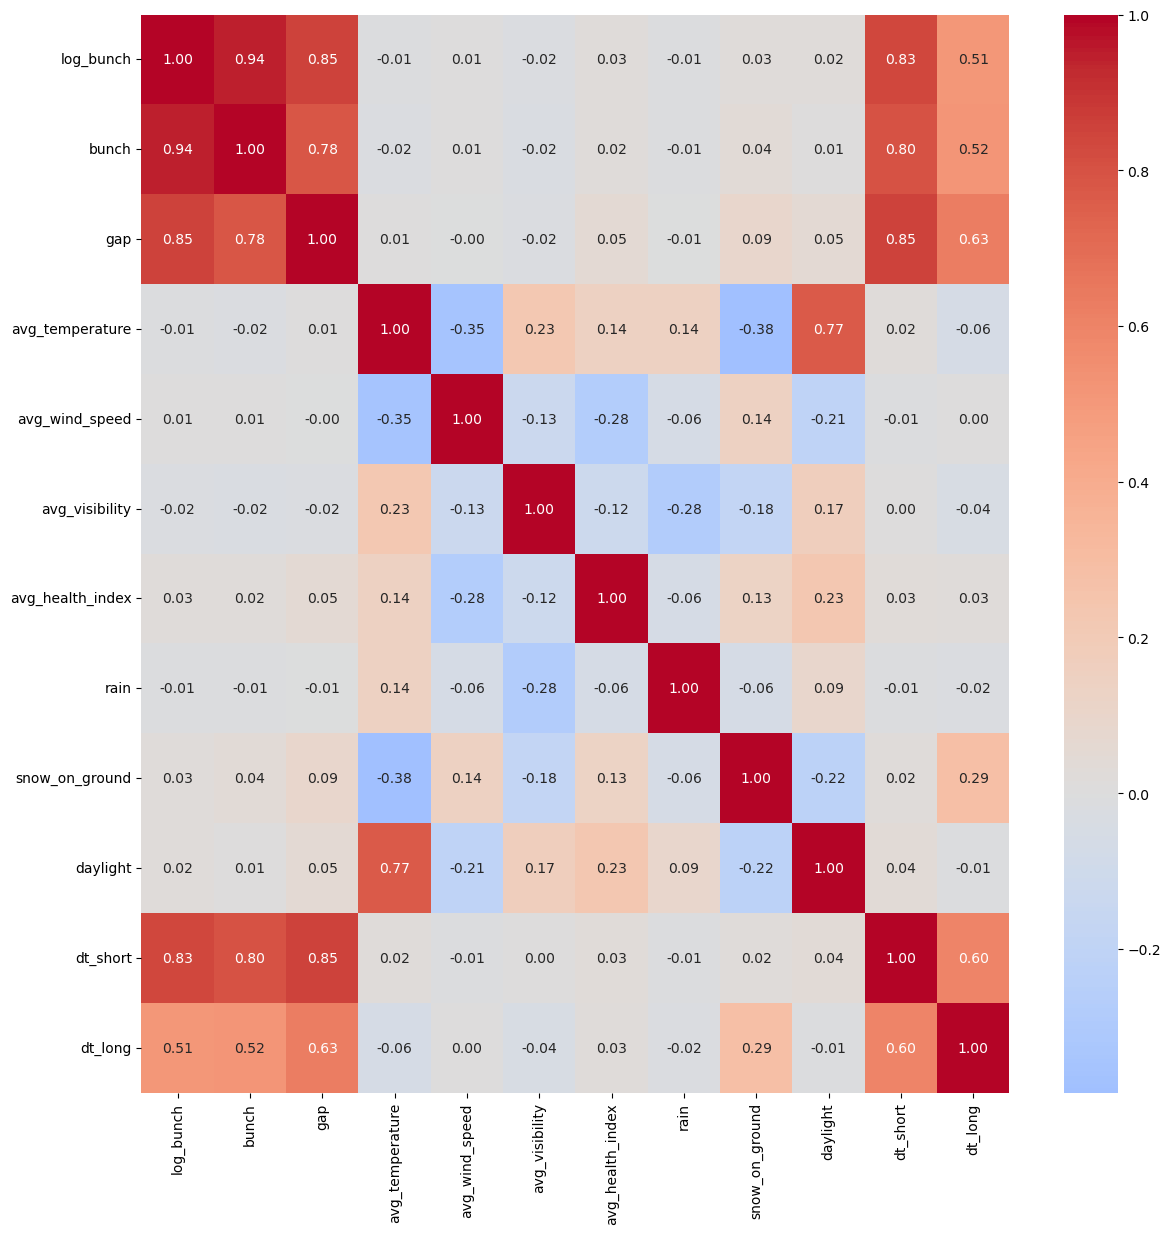

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f')
plt.show()

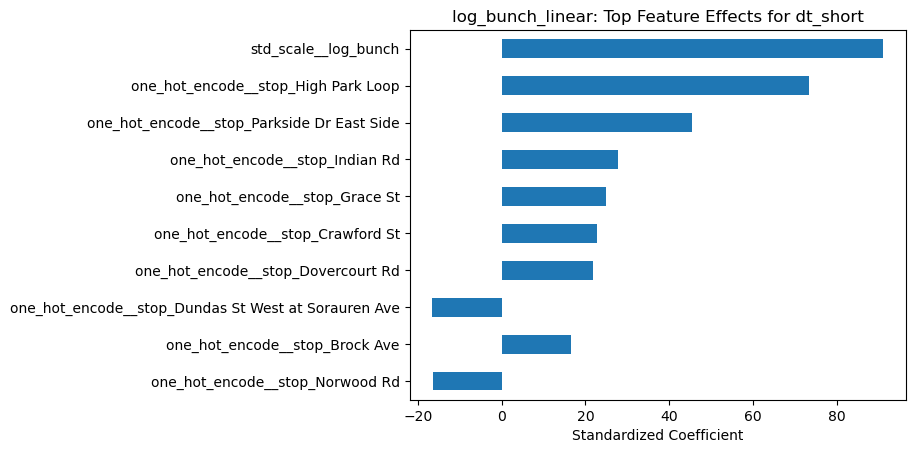

The results:
log_bunch_linear dt_short rmse: [74.03978883]
log_bunch_linear dt_short R^2 score: [0.40463149]


In [11]:
## Modeling configurations with different choices of features and transformations: 

final_models = {
    "log_bunch_linear": {
         "targets": {"dt_short": "dt_short"},
        "cat features": ['dir', 'stop'],
        "num features": ['log_bunch', 'avg_temperature', 'avg_wind_speed','avg_visibility', 
                     'avg_health_index', 'rain','snow_on_ground', 
                     'daylight']
    }
}

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder



loss = dict()
R2_score = dict()


for model_name, config in final_models.items():
    num_features = config["num features"]
    cat_features = config["cat features"]
    features = num_features + cat_features

    preprocessor = ColumnTransformer(
            transformers=[
                ("std_scale", StandardScaler(), num_features),
                ("one_hot_encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
            ],
            remainder="drop"
        )


    for target_name, target_col in config["targets"].items():
        
        X_train = train_daily_df[features].copy()
        X_test = test_daily_df[features].copy()

        y_train = train_daily_df[target_col].copy()
        y_test = test_daily_df[target_name].copy()

    ## One-hot encode categorical variables

        model_pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", LinearRegression())
        ])

            
            
        model_pipe.fit(X_train, y_train)
        y_pred = model_pipe.predict(X_test)

## Back transform the transformed targets for comparison
        if "log" in target_col:
            y_pred = np.expm1(y_pred)

        R2_score[(model_name, target_name)] = r2_score(y_test, y_pred)
        loss[(model_name, target_name)] = rmse(y_test, y_pred)

            
        coefs = pd.Series(model_pipe.named_steps["model"].coef_, 
                          index=model_pipe.named_steps["preprocess"].get_feature_names_out())

        coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

        plt.figure()
        coefs_sorted.head(10).plot(kind='barh')
        plt.title(f"{model_name}: Top Feature Effects for {target_col}")
        plt.xlabel("Standardized Coefficient")
        plt.gca().invert_yaxis()
        plt.show()


        print(f"The results:")
        print(f'{model_name} {target_col} rmse: {np.array([val for key, val in loss.items() if key[0] == model_name and key[1] == target_col])}')
        print(f'{model_name} {target_col} R^2 score: {np.array([val for key, val in R2_score.items() if key[0] == model_name and key[1] == target_col])}')


The residual plot also looks fairly normal, with the exception of a hard cut-off on the line $y=-x$, from the fact that the test values can never be negative (and hence no value can go below $y=-x$.

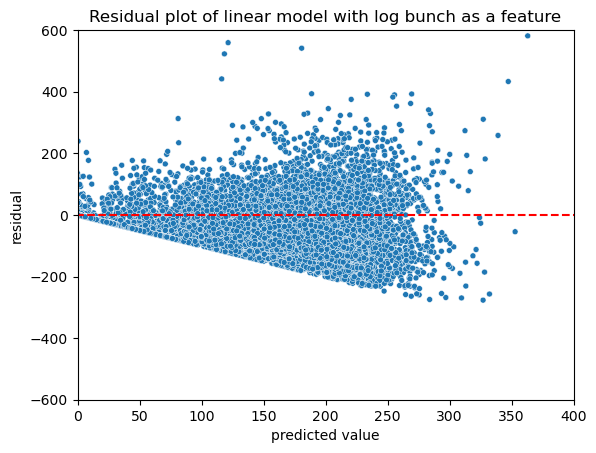

In [12]:
y_resid = y_test - y_pred

sns.scatterplot(x = y_pred,y = y_resid, size=5, legend=False)
sns.lineplot(x=[y_pred.min(), y_pred.max()], y=[0,0], color='red', linestyle='--')
plt.xlabel('predicted value')
plt.ylabel('residual')
plt.ylim(-600,600)
plt.xlim(0,400)
plt.title('Residual plot of linear model with log bunch as a feature')
plt.show()

We also run the test for xgboost and get similar results.

In [13]:
import xgboost as xgb

features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']


X_test = test_daily_df[[x for x in features]]
y_test = test_daily_df['dt_short']

X_train = train_daily_df[[x for x in features]]
y_train = train_daily_df['dt_short']

model = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=100,
                        enable_categorical=True,
                        learning_rate=0.1,
                        subsample=0.7,
                        max_depth=5,
                        reg_lambda=1,
                        reg_alpha=10,
                        seed=37)

model.fit(X_train, y_train)

xgboost_pred = model.predict(X_test)

rmse_xgboost = rmse(y_test,xgboost_pred)
r2_xgboost = r2_score(y_test,xgboost_pred)

print(f'Performance of xgboost model RMSE: {rmse_xgboost}')
print(f'Performance of xgboost model R2 score: {r2_xgboost}')

Performance of xgboost model RMSE: 72.72511968327822
Performance of xgboost model R2 score: 0.425586806655213


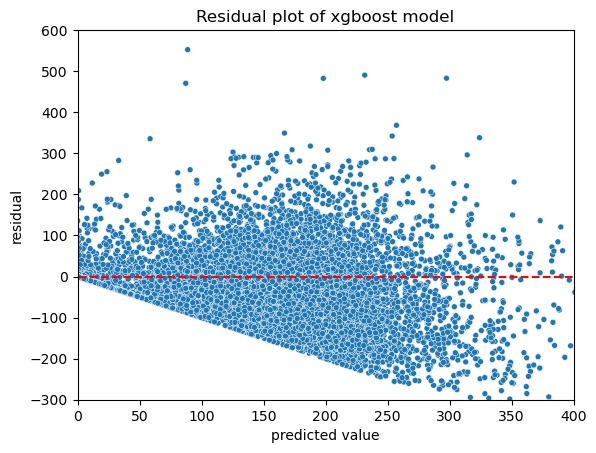

In [21]:
xgboost_resid = y_test-xgboost_pred

sns.scatterplot(x = xgboost_pred,y = xgboost_resid, size=5, legend=False)
sns.lineplot(x=[xgboost_pred.min(), xgboost_pred.max()], y=[0,0], color='red', linestyle='--')
plt.xlabel('predicted value')
plt.ylabel('residual')
plt.ylim(-300,600)
plt.xlim(0,400)
plt.title('Residual plot of xgboost model')
plt.show()

Below is a plot of dt_short vs date of our models and the test data. Note that our model faily consistently overestimates the delay time.

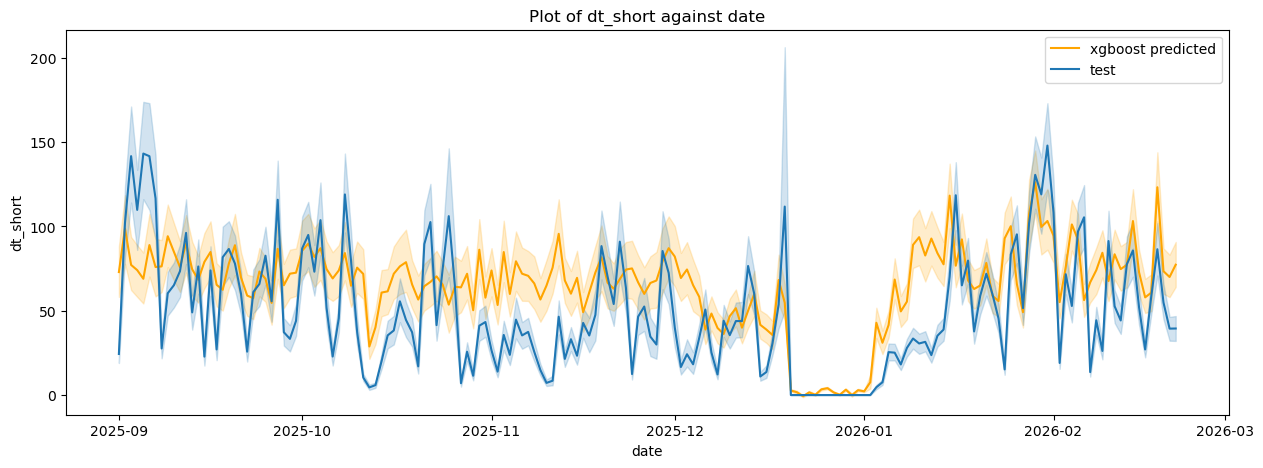

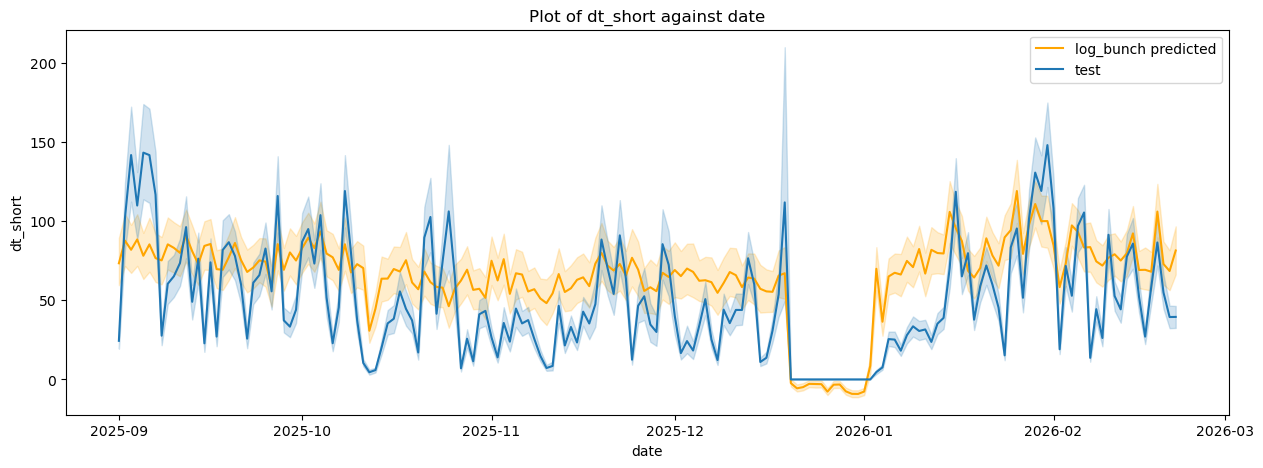

In [22]:
plt.figure(figsize=(15,5))
sns.lineplot(x=test_daily_df['date'], y=xgboost_pred, color='orange', label='xgboost predicted')
sns.lineplot(x=test_daily_df['date'], y=test_daily_df['dt_short'], label='test')
plt.legend()
plt.ylabel('dt_short')
plt.xlabel('date')
plt.title('Plot of dt_short against date')
plt.show()

plt.figure(figsize=(15,5))
sns.lineplot(x=test_daily_df['date'], y=y_pred, color='orange', label='log_bunch predicted')
sns.lineplot(x=test_daily_df['date'], y=test_daily_df['dt_short'], label='test')
plt.legend()
plt.ylabel('dt_short')
plt.xlabel('date')
plt.title('Plot of dt_short against date')
plt.show()

In [15]:
baseline = dict()

for stop in train_daily_df.stop.unique():
    for dir in ['E', 'W']:
        baseline[stop, dir] = train_daily_df[(train_daily_df['stop'] == stop) & (train_daily_df['dir'] == dir)]['dt_short'].mean()

baseline_df = test_daily_df[['dir', 'stop']].copy()

dt_list = []

for row in range(baseline_df.shape[0]):
    curr_stop = baseline_df['stop'].iloc[row]
    curr_dir = baseline_df['dir'].iloc[row]

    dt_list.append(baseline[curr_stop, curr_dir])

baseline_df['dt_short'] = dt_list

rmse_baseline = rmse(test_daily_df['dt_short'], baseline_df['dt_short'])
r2_baseline= r2_score(test_daily_df['dt_short'], baseline_df['dt_short'])
print(f'Performance of baseline model RMSE: {rmse_baseline}')

Performance of baseline model RMSE: 91.35260592051911


Note that the training set is quite imbalanced, which is simply a feature of streetcars generally arriving at their stop on time. For example, in [this report](https://www.toronto.ca/legdocs/mmis/2025/ttc/bgrd/backgroundfile-259672.pdf), they point out that streetcars on the 506 line in the week of October 6th 2025 arrived to within 5 minutes 59% of the time. Indeed, they note in the report that TTC intervention has improved the service of this line from 54% in 2024.

In [20]:
# Calculate the ratio of on time stops in a day vs not on time stops.
on_time = len([x for x in train_daily_df['dt_short'] if x == 0])

prob = on_time/len(train_daily_df['dt_short'])

print(f'Probability of arriving on time: {prob}')

Probability of arriving on time: 0.5985578577820609


Since there are so many on time arrivals, we quickly check to see if a model that simply predicts all streetcars will arrive on time does anything.

In [17]:
baseline_zero = dict()

for stop in train_daily_df.stop.unique():
    for dir in ['E', 'W']:
        baseline_zero[stop, dir] = 0

baseline_zero_df = test_daily_df[['dir', 'stop']].copy()

dt_list = []

for row in range(baseline_zero_df.shape[0]):
    curr_stop = baseline_zero_df['stop'].iloc[row]
    curr_dir = baseline_zero_df['dir'].iloc[row]

    dt_list.append(baseline_zero[curr_stop, curr_dir])

baseline_zero_df['dt_short'] = dt_list

rmse_baseline_zero = rmse(test_daily_df['dt_short'], baseline_zero_df['dt_short'])
r2_baseline_zero= r2_score(test_daily_df['dt_short'], baseline_zero_df['dt_short'])
print(f'Performance of zero model RMSE: {rmse_baseline_zero}')
print(f'Performance of zero model R2: {r2_baseline_zero}')

Performance of zero model RMSE: 108.0474112071019
Performance of zero model R2: -0.2678978009631068


Since the $R^2$ value is very negative, we reject this model outright. Finally, we have a plot of our metrics.

,model,rmse,R2
0,log_bunch_linear,74.039789,0.404631
1,xgboost,72.725120,0.425587
2,baseline,91.352606,0.093647


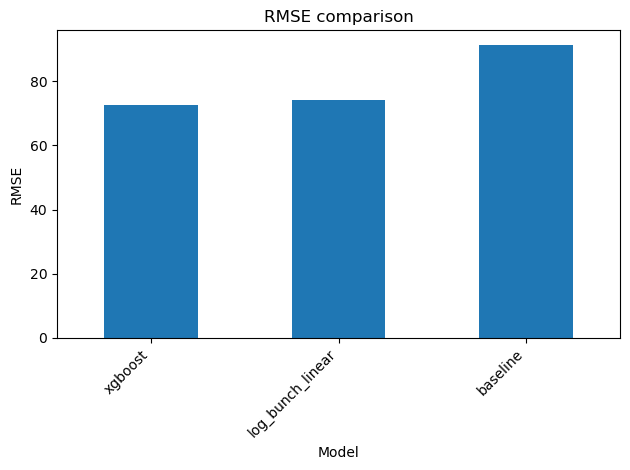

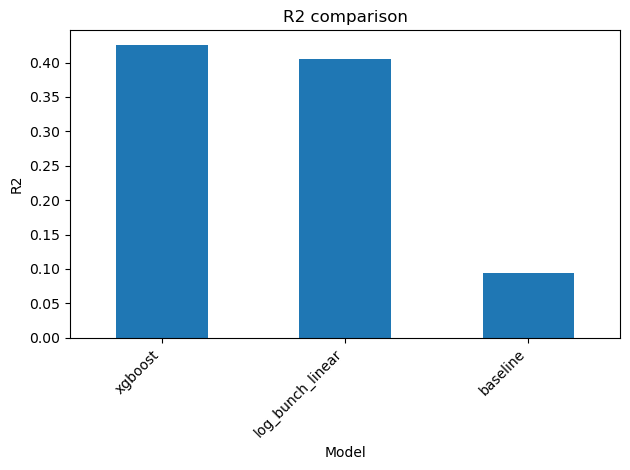

In [18]:
# Once the results are all in the dictionary for loss and r2_score as {(model_name, target): number}
# plot the bar graphs by first combining into a dataframe

results_dict = []

for key, val in loss.items():
    results_dict.append(
        {
            "model": key[0],
            "rmse": val,
            "R2": R2_score[(key[0], key[1])]
        }
    )

results_dict.append({
            "model": 'xgboost',
            "rmse": rmse_xgboost,
            "R2": r2_xgboost
})

results_dict.append({
            "model": 'baseline',
            "rmse": rmse_baseline,
            "R2": r2_baseline
})



results_df = pd.DataFrame(results_dict) 
display(results_df)

## Then plot the bar graphs of the models for each target for rmse and r2


# rmse 
df_rmse = results_df.sort_values("rmse", ascending=True)
df_rmse.plot(x="model", y="rmse", kind="bar", legend=False)
plt.title(f"RMSE comparison")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# R^2
df_R2 = results_df.sort_values("rmse", ascending=True)
df_R2.plot(x="model", y="R2", kind="bar", legend=False)
plt.title(f"R2 comparison")
plt.ylabel("R2")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The $R^2$ score shows a significant boost in predictability from the baseline, and about a 20% improvement in terms of RMSE.